In [6]:
import MDAnalysis as mda
#from lipyphilic.lib.z_positions import ZThickness
#import lipyphilic.lib.z_thickness as ZThickness
from MDAnalysis.analysis.leaflet import LeafletFinder
import MDAnalysis.analysis.distances as dist
import seaborn as sns

ImportError: cannot import name 'gcd' from 'fractions' (/home/dell/anaconda3/lib/python3.9/fractions.py)

In [121]:
#With-Calcium

NeutralCa_u = mda.Universe('Neutral-with-Ca.gro','Neutral-with-Ca.xtc')
twoCa_u = mda.Universe('+2-with-Ca.gro','+2-with-Ca.xtc')
fourCa_u = mda.Universe('+4-with-Ca.gro','+4-with-Ca.xtc')
fiveCa_u = mda.Universe('+5-with-Ca.gro','+5-with-Ca.xtc')

In [122]:
#Without-Calcium

Neutral_u = mda.Universe('Neutral-without-calcium.gro','Neutral-without-Calcium.xtc')
two_u = mda.Universe('+2-without-calcium.gro','+2-without-calcium.xtc')
four_u = mda.Universe('+4-without-calcium.gro','+4-without-calcium.xtc')
five_u = mda.Universe('+5-without-calcium.gro','+5-without-calcium.xtc')

In [123]:
Neutral_Ca_L = LeafletFinder(NeutralCa_u, 'name P*')
Two_Ca_L = LeafletFinder(twoCa_u,'name P*')
Four_Ca_L = LeafletFinder(fourCa_u,'name P*')
Five_Ca_L = LeafletFinder(fiveCa_u,'name P*')

In [124]:
Neutral_Ca_leaflet0 = Neutral_Ca_L.groups(0)
Neutral_Ca_leaflet1 = Neutral_Ca_L.groups(1)

Two_Ca_leaflet0 = Two_Ca_L.groups(0)
Two_Ca_leaflet1 = Two_Ca_L.groups(1)

Four_Ca_leaflet0 = Four_Ca_L.groups(0)
Four_Ca_leaflet1 = Four_Ca_L.groups(1)

Five_Ca_leaflet0 = Five_Ca_L.groups(0)
Five_Ca_leaflet1 = Five_Ca_L.groups(1)

In [125]:
Neutral_L = LeafletFinder(Neutral_u,'name P*')
Two_L = LeafletFinder(two_u,'name P*')
Four_L = LeafletFinder(four_u,'name P*')
Five_L = LeafletFinder(five_u,'name P*')

In [126]:
Neutral_leaflet0 = Neutral_L.groups(0)
Neutral_leaflet1 = Neutral_L.groups(1)

Two_leaflet0 = Two_L.groups(0)
Two_leaflet1 = Two_L.groups(1)

Four_leaflet0 = Four_L.groups(0)
Four_leaflet1 = Four_L.groups(1)

Five_leaflet0 = Five_L.groups(0)
Five_leaflet1 = Five_L.groups(1)

In [140]:
def thickness(dis,time,x,y1,y2):
    for ts in x.trajectory:
        group0_coords = y1.residues.atoms.center_of_mass()
        group1_coords = y2.residues.atoms.center_of_mass()
        #d = group0_coords - group1_coords
        d = dist.distance_array(group0_coords, group1_coords)
        dis.append(d.min()/10)
        #dis.append(d/10)
        time.append(ts.frame/10)

In [141]:
Neutral_Ca_distances = []
Neutral_distances = []

Two_Ca_distances = []
Two_distances = []

Four_Ca_distances = []
Four_distances = []

Five_Ca_distances = []
Five_distances = []

In [142]:
Neutral_Ca_timestamps = []
Neutral_timestamps = []

Two_Ca_timestamps = []
Two_timestamps = []

Four_Ca_timestamps = []
Four_timestamps = []

Five_Ca_timestamps = []
Five_timestamps = []

In [143]:
thickness(Neutral_Ca_distances,Neutral_Ca_timestamps,NeutralCa_u,Neutral_Ca_leaflet0,Neutral_Ca_leaflet1)
thickness(Two_Ca_distances,Two_Ca_timestamps,twoCa_u,Two_Ca_leaflet0,Two_Ca_leaflet1)
thickness(Four_Ca_distances,Four_Ca_timestamps,fourCa_u,Four_Ca_leaflet0,Four_Ca_leaflet1)
thickness(Five_Ca_distances,Five_Ca_timestamps,fiveCa_u,Five_Ca_leaflet0,Five_Ca_leaflet1)

In [144]:
thickness(Neutral_distances,Neutral_timestamps,Neutral_u,Neutral_leaflet0,Neutral_leaflet1)
thickness(Two_distances,Two_timestamps,two_u,Two_leaflet0,Two_leaflet1)
thickness(Four_distances,Four_timestamps,four_u,Four_leaflet0,Four_leaflet1)
thickness(Five_distances,Five_timestamps,five_u,Five_leaflet0,Five_leaflet1)

In [146]:
avg_thickness = sum(Neutral_Ca_distances) / len(Neutral_Ca_distances)
print(avg_thickness)

2.7213478777687476


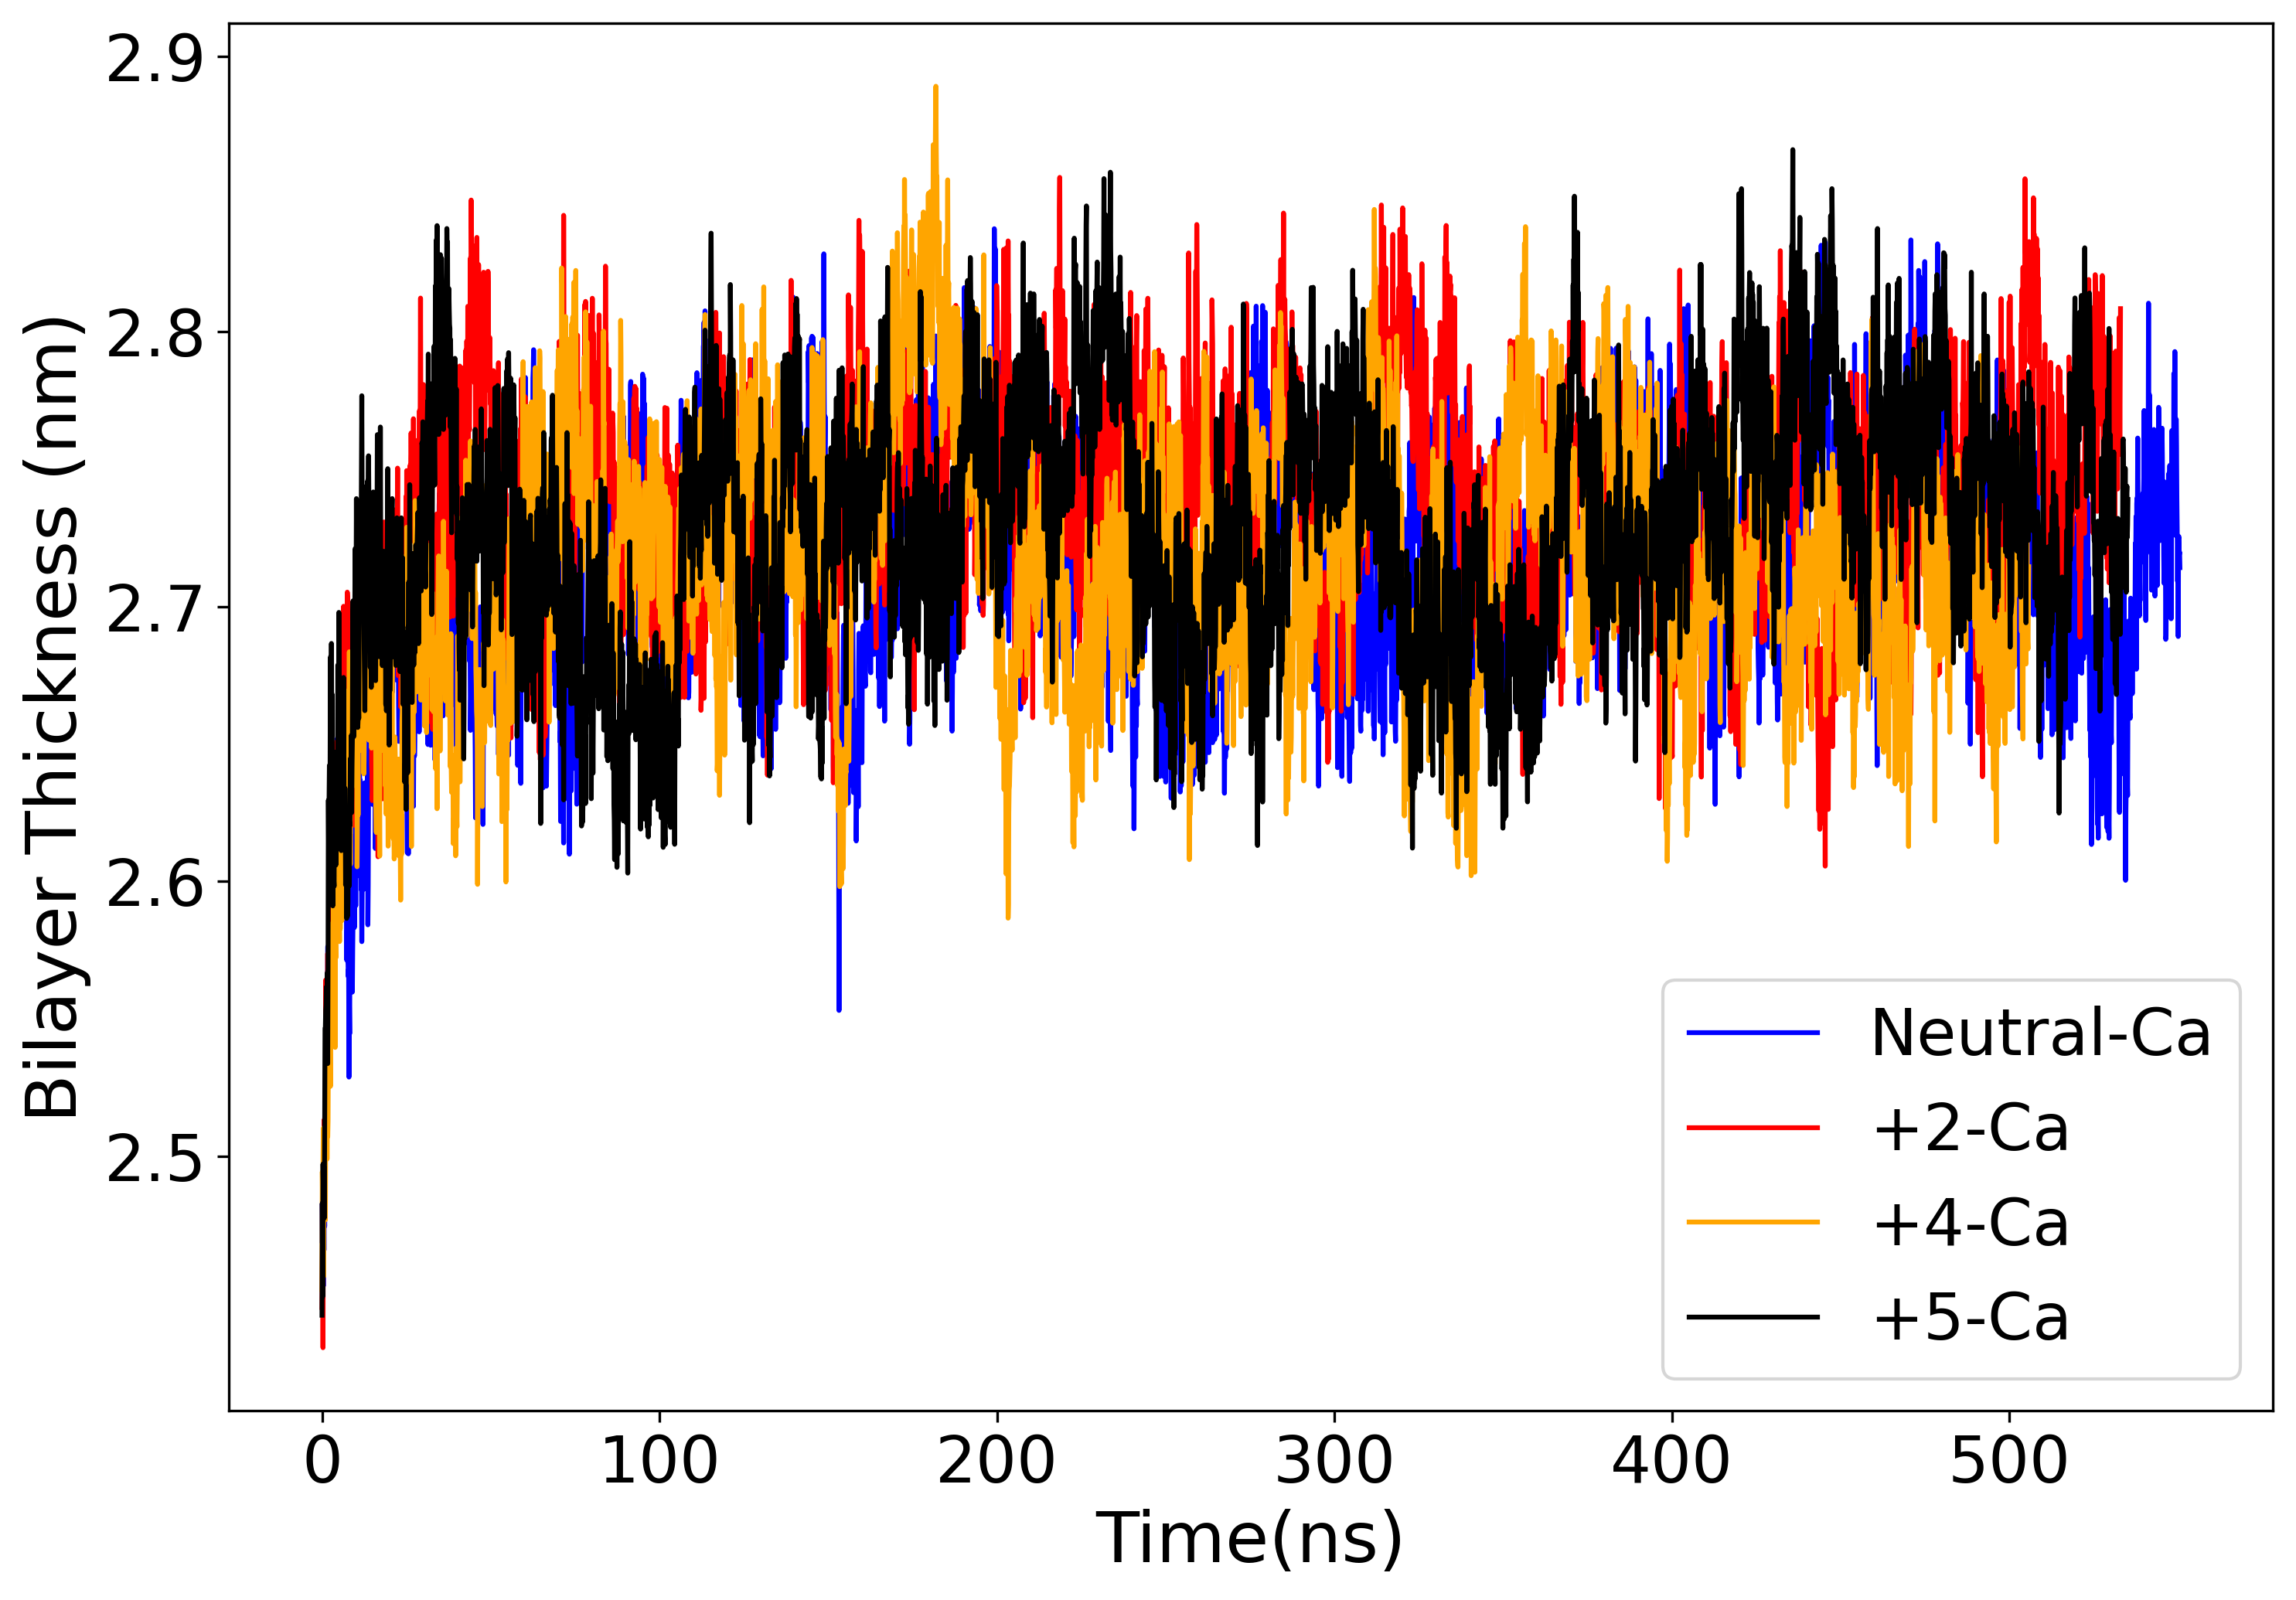

In [131]:
import matplotlib.pyplot as plt

plt.figure(figsize=[10,7],dpi=300)
plt.plot(Neutral_Ca_timestamps,Neutral_Ca_distances,color="blue",label=("Neutral-Ca"))
plt.plot(Two_Ca_timestamps,Two_Ca_distances,color="red",label="+2-Ca")
plt.plot(Four_Ca_timestamps,Four_Ca_distances,color="orange",label="+4-Ca")
plt.plot(Five_Ca_timestamps,Five_Ca_distances,color="black",label="+5-Ca")
#plt.plot(Neutral_Ca1[0],Neutral_Ca1[1],color="#00FF00",label="Neutral-Ca")
#plt.plot(Two_Ca1[0],Two_Ca1[1],color="#308014",label="+2-Ca")
#plt.plot(Four_Ca1[0],Four_Ca1[1],color="#BF3EFF",label="+4-Ca")
#plt.plot(Five_Ca1[0],Five_Ca1[1],color="#F08080",label="+5-Ca")

#bbox_to_anchor=(1.05,0.7)
#plt.legend(loc = 'center left',bbox_to_anchor=(1,0.7),handlelength=1,fontsize=20)
plt.legend(loc = 'lower right',fontsize=20)
plt.xlabel("Time(ns)",fontsize=22)
#x_ticks = plt.xticks()[0]
#x_ticks +=8
plt.xticks(fontsize=20)
plt.ylabel("Bilayer Thickness (nm)",fontsize=22)
plt.yticks(fontsize=20)
plt.tight_layout()
#plt.savefig("Updated_RMSF_color.png")

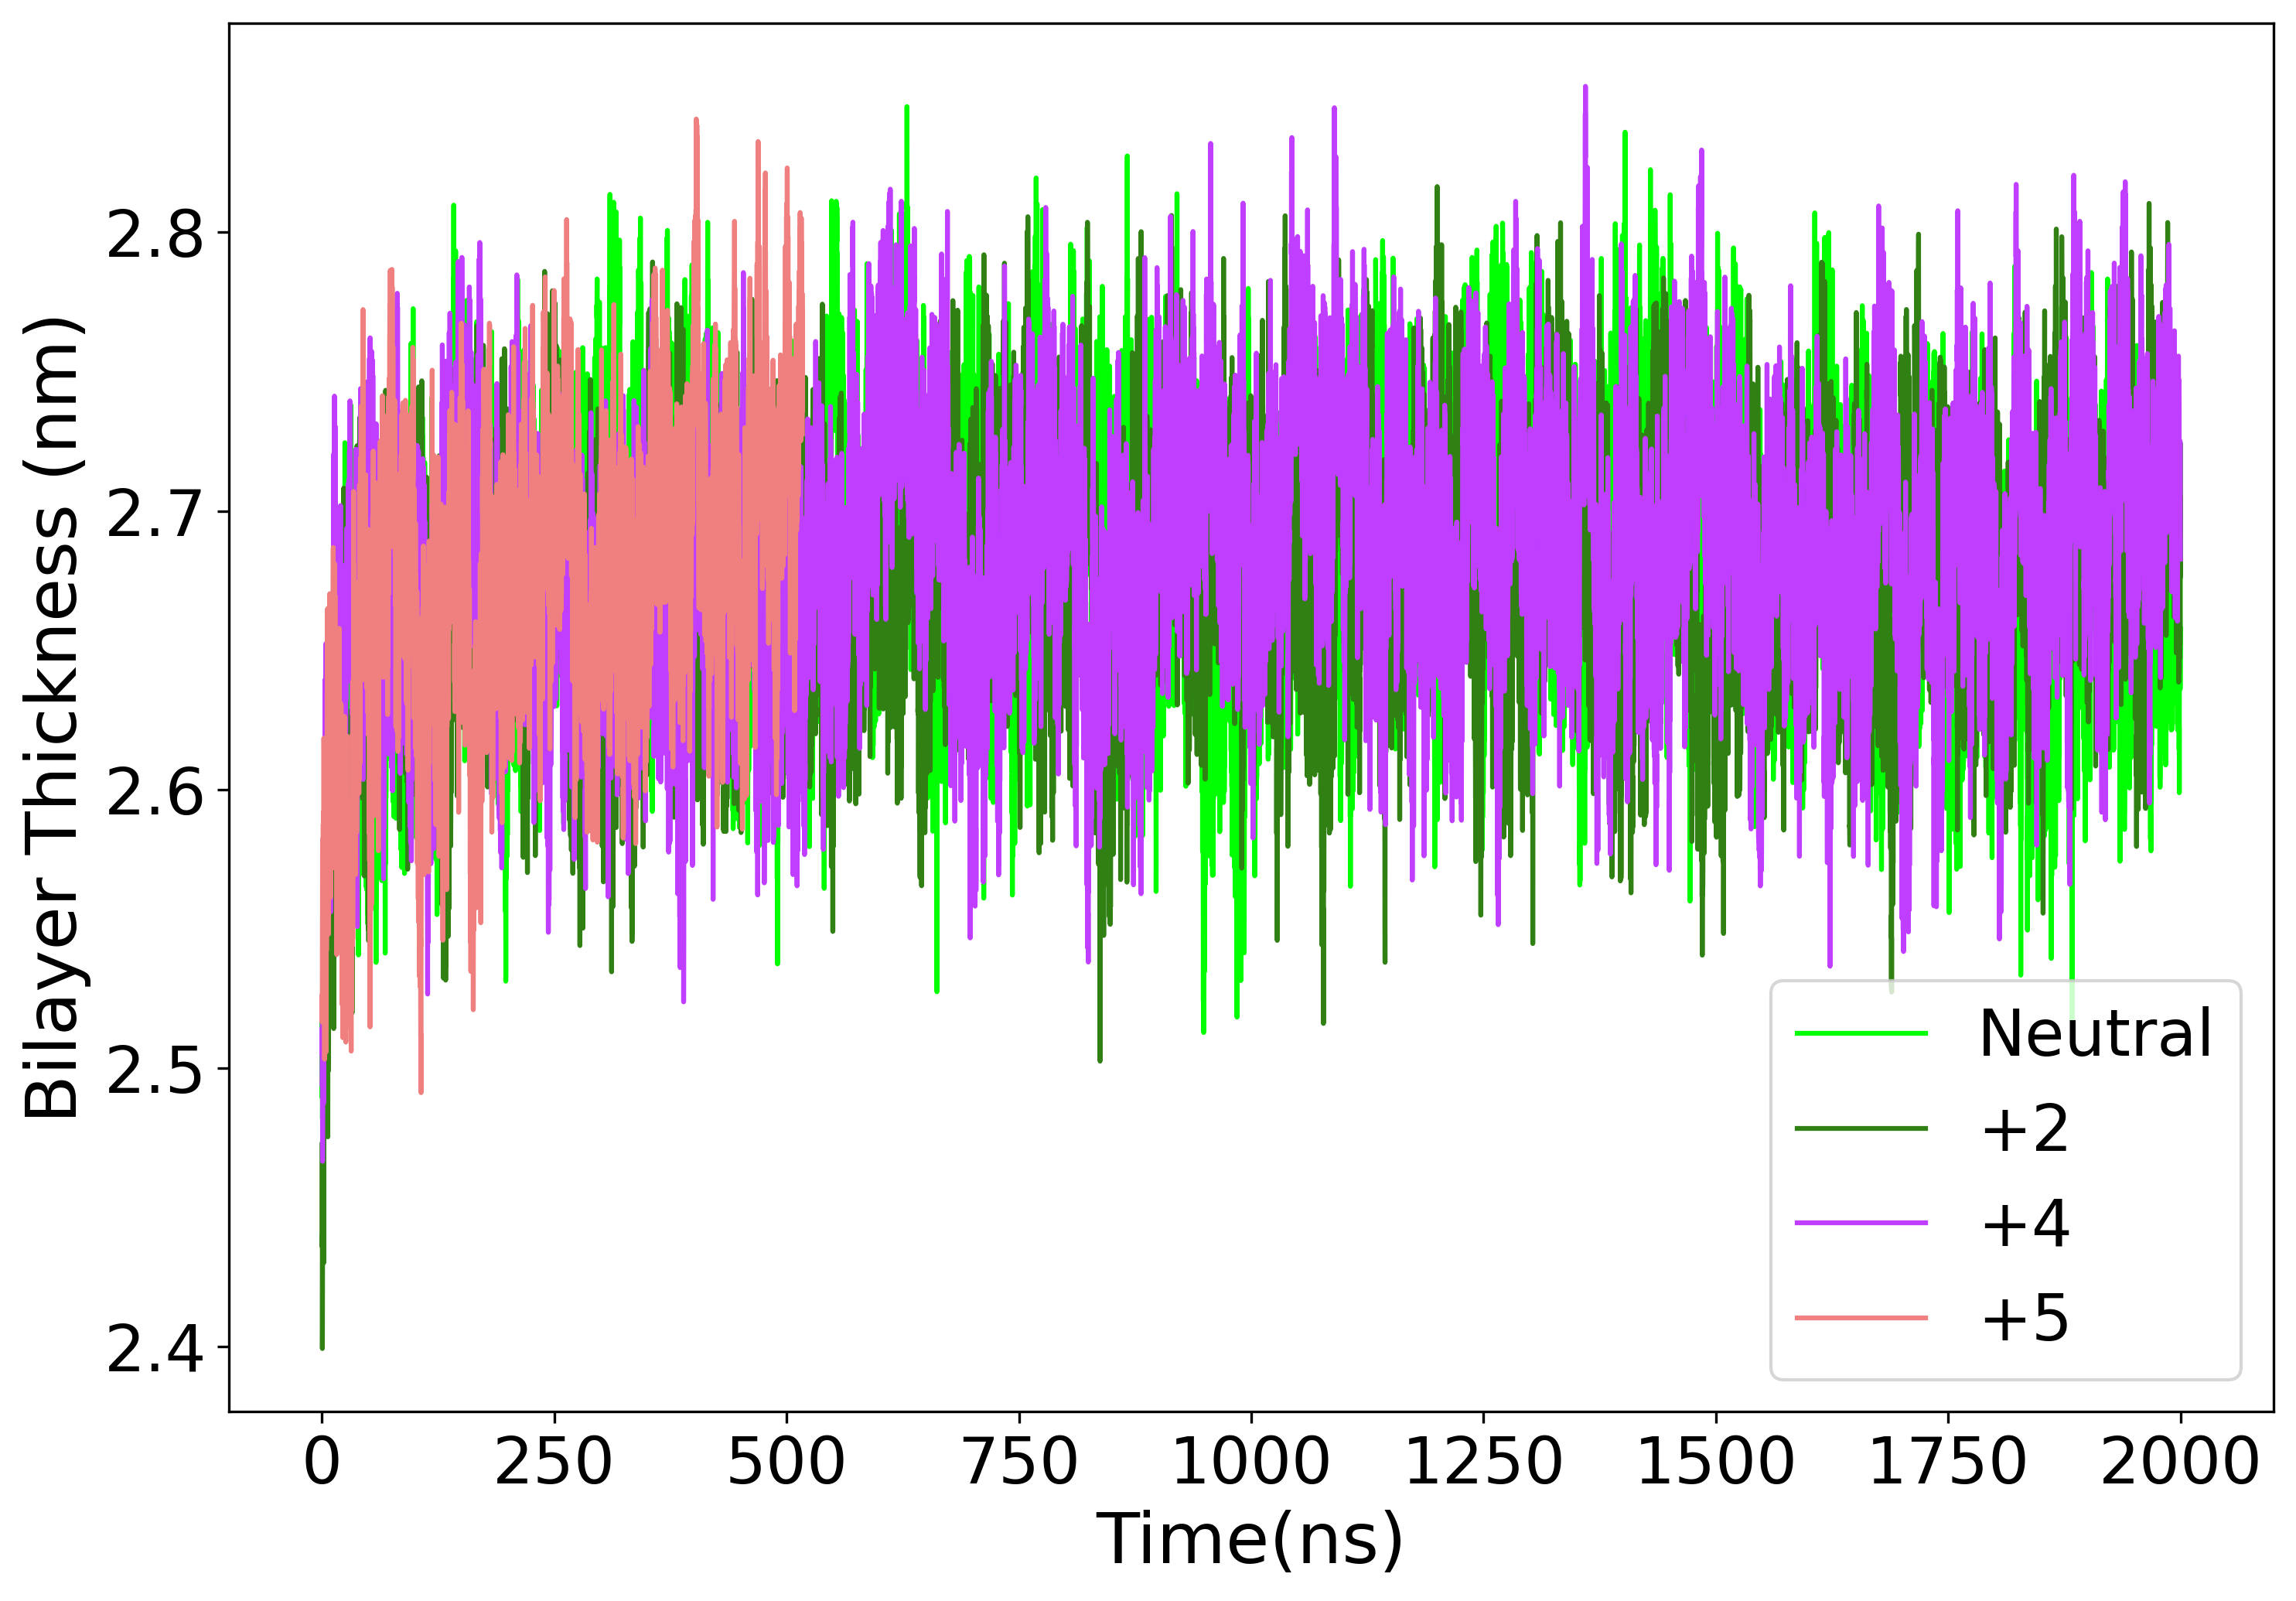

In [133]:
plt.figure(figsize=[10,7],dpi=300)

plt.plot(Neutral_timestamps,Neutral_distances,color="#00FF00",label="Neutral")
plt.plot(Two_timestamps,Two_distances,color="#308014",label="+2")
plt.plot(Four_timestamps,Four_distances,color="#BF3EFF",label="+4")
plt.plot(Five_timestamps,Five_distances,color="#F08080",label="+5")

plt.legend(loc = 'lower right',fontsize=20)
plt.xlabel("Time(ns)",fontsize=22)
plt.xticks(fontsize=20)
plt.ylabel("Bilayer Thickness (nm)",fontsize=22)
plt.yticks(fontsize=20)
plt.tight_layout()

In [135]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
sns.set_style('white')
%matplotlib inline
#import csv

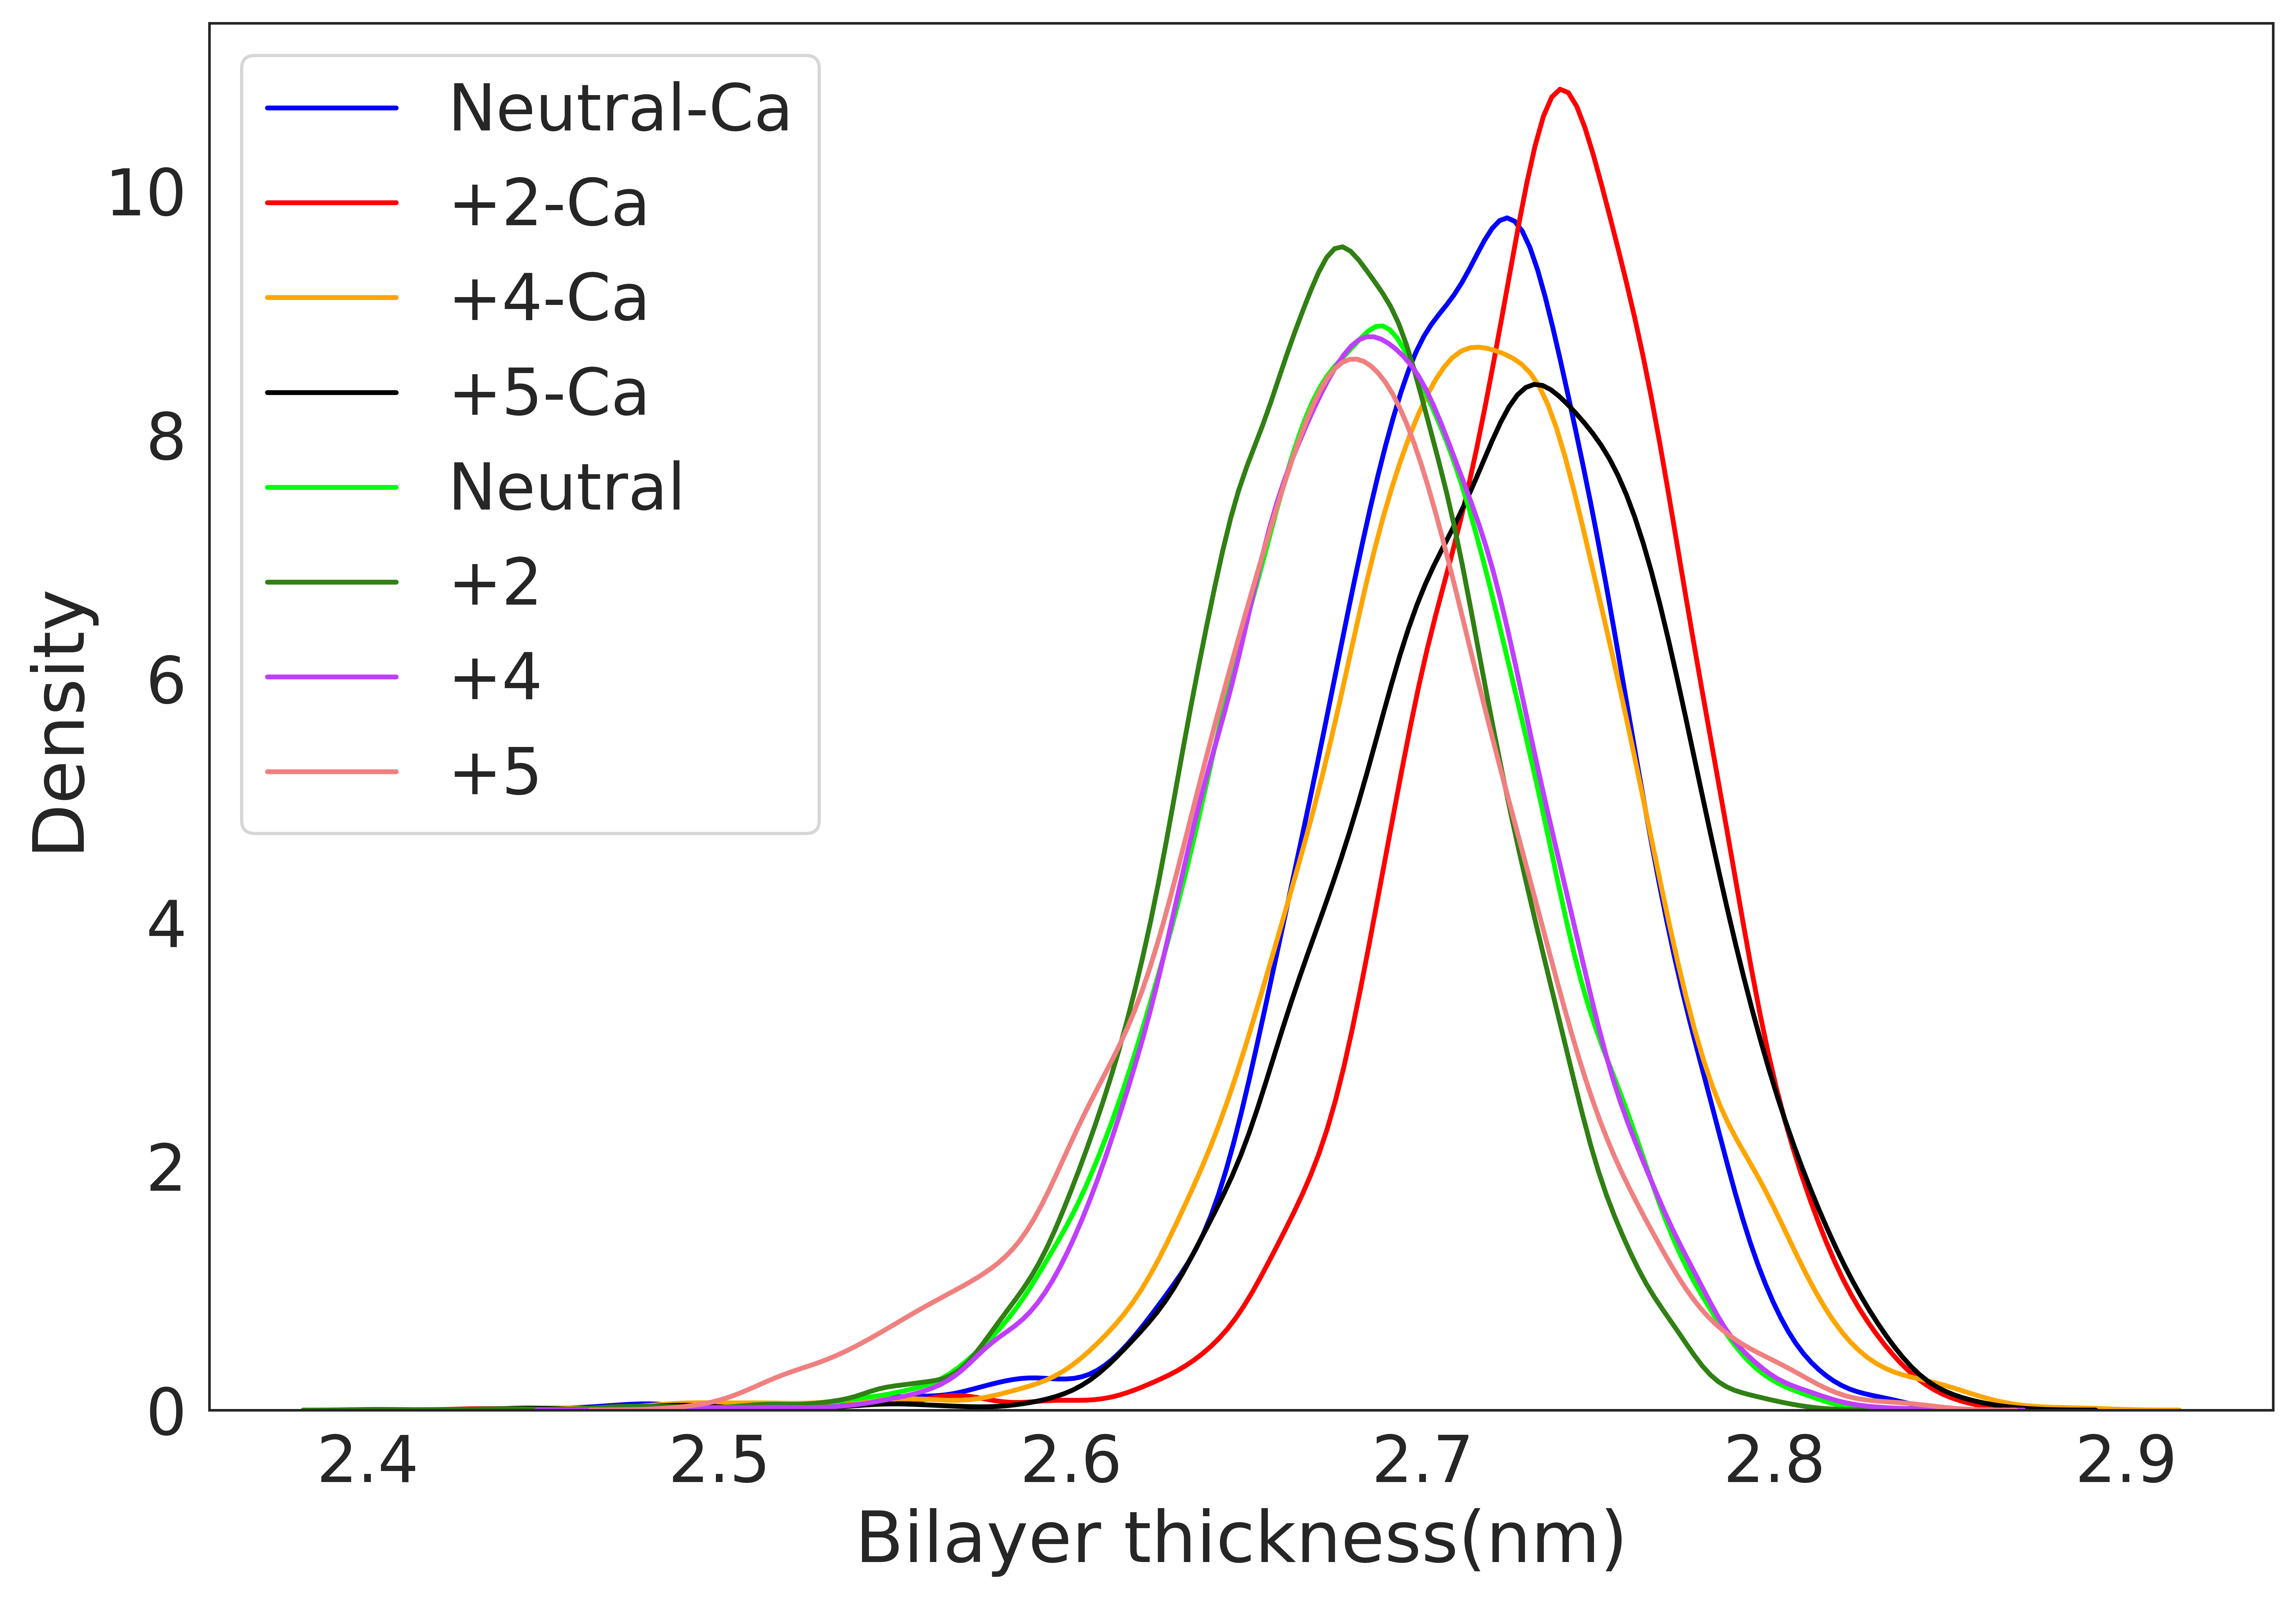

In [136]:
sns.set_palette("tab10")

plt.figure(figsize=[10,7],dpi=800)
sns.kdeplot(Neutral_Ca_distances,color="blue",label="Neutral-Ca")
sns.kdeplot(Two_Ca_distances,color="red",label="+2-Ca")
sns.kdeplot(Four_Ca_distances,color="orange",label="+4-Ca")
sns.kdeplot(Five_Ca_distances,color="black",label="+5-Ca")
sns.kdeplot(Neutral_distances,color="#00FF00",label="Neutral")
sns.kdeplot(Two_distances,color="#308014",label="+2")
sns.kdeplot(Four_distances,color="#BF3EFF",label="+4")
sns.kdeplot(Five_distances,color="#F08080",label="+5")
#plt.plot(f8[0],f8[1],".-",color="#20B2AA",label="+2 with Ca")
#plt.axvline(x=4.3, color='black',linewidth=3,linestyle='dashed')
plt.legend(loc = 'upper left',fontsize=20)
#plt.xlim(-5,45)
plt.xlabel("Bilayer thickness(nm)",fontsize=22)
plt.xticks(fontsize=20)
plt.ylabel("Density",fontsize=22)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.savefig("Bilayer_thickness.png")

In [1]:




from scipy.signal import find_peaks
#data = np.random.normal(size=1000)
#sns.kdeplot(data)
peaks, _ = find_peaks(sns.kdeplot(Neutral_Ca_distances).get_lines()[0].get_ydata())

peak_x = sns.kdeplot(Neutral_Ca_distances).get_lines()[0].get_xdata()[peaks]
print("Peak value(s)of Neutral-Ca is:", peak_x)

NameError: name 'sns' is not defined

In [ ]:
peaks, _ = find_peaks(sns.kdeplot(Two_Ca_distances).get_lines()[0].get_ydata())
peak_x = sns.kdeplot(Two_Ca_distances).get_lines()[0].get_xdata()[peaks]
print("Peak value(s)of Two-Ca is:", peak_x)

In [ ]:
peaks, _ = find_peaks(sns.kdeplot(Four_Ca_distances).get_lines()[0].get_ydata())
peak_x = sns.kdeplot(Four_Ca_distances).get_lines()[0].get_xdata()[peaks]
print("Peak value(s)of Four-Ca is:", peak_x)

Peak value(s)of Five-Ca is: [2.45128563 2.4584905  2.49451487 2.56896524 2.74188221]


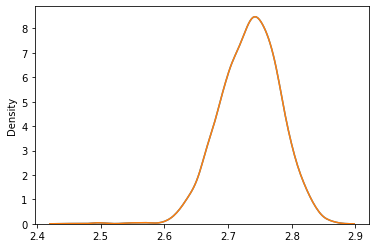

In [104]:
dis.append(d/10)
    timestamp.append(ts.frame/10)peaks, _ = find_peaks(sns.kdeplot(Five_Ca_distances).get_lines()[0].get_ydata())

peak_x = sns.kdeplot(Five_Ca_distances).get_lines()[0].get_xdata()[peaks]

print("Peak value(s)of Five-Ca is:", peak_x)

In [145]:
import statistics

Neutral_Ca_mean_value = statistics.mean(Neutral_Ca_distances)
Two_Ca_mean_value = statistics.mean(Two_Ca_distances)
Four_Ca_mean_value = statistics.mean(Four_Ca_distances)
Five_Ca_mean_value = statistics.mean(Five_Ca_distances)

Neutral_mean_value = statistics.mean(Neutral_distances)
Two_mean_value = statistics.mean(Two_distances)
Four_mean_value = statistics.mean(Four_distances)
Five_mean_value = statistics.mean(Five_distances)


print("Mean value of Neutral-Ca is:",Neutral_Ca_mean_value)
print("Mean value of Two-Ca is:",Two_Ca_mean_value)
print("Mean value of Four-Ca is:",Four_Ca_mean_value)
print("Mean value of Five-Ca is:",Five_Ca_mean_value)


print("Mean value of Neutral is:",Neutral_mean_value)
print("Mean value of Two is:",Two_mean_value)
print("Mean value of Four is:",Four_mean_value)
print("Mean value of Five is:",Five_mean_value)

Mean value of Neutral-Ca is: 2.7213478777687405
Mean value of Two-Ca is: 2.743558823055966
Mean value of Four-Ca is: 2.721170898786643
Mean value of Five-Ca is: 2.7341276779428316
Mean value of Neutral is: 2.6917647446648356
Mean value of Two is: 2.682874608960922
Mean value of Four is: 2.692891561469322
Mean value of Five is: 2.6810626865397467


In [28]:
distances = []
timestamp = []
for ts in NeutralCa_u.trajectory:
    group0_coords = leaflet0.residues.atoms.center_of_mass()
    group1_coords = leaflet1.residues.atoms.center_of_mass()
    d = dist.distance_array(group0_coords, group1_coords)
    distances.append(d.min()/10)
    timestamp.append(ts.frame/10)
#thickness = distances / len(distances)

In [13]:
z_thickness = ZThickness(
  universe=u,
  lipid_sel="(name ??1 ??A) or (resname CHOL and not name ROH)"
)

z_thickness.run()

TypeError: 'module' object is not callable

In [33]:
memb_thickness = MembThickness(
  universe=u,
  leaflets=leaflets.filter_leaflets(leaflet0 ,leaflet1),  # exclude cholesterol from thickness calculation
  lipid_sel="name P*"
)

memb_thickness.run()

AttributeError: AtomGroup has no attribute replace. 

In [4]:
import MDAnalysis as mda
from lipyphilic.lib.assign_leaflets import AssignLeaflets
from lipyphilic.lib.z_thickness import ZThickness
from lipyphilic.lib.memb_thickness import MembThickness

In [19]:
u = mda.Universe('Neutral-with-Ca.gro','Neutral-with-Ca.xtc')

leaflets = AssignLeaflets(
  universe=u,
  lipid_sel="name P*"
)
leaflets.run(start=None, stop=None, step=None)

In [ ]:
 POPC, POPE, POPI, POPS, and CHOL in

In [93]:
print(leaflets)

NameError: name 'leaflets' is not defined

In [163]:
distance = []
timestamp = []

for ts in NeutralCa_u.trajectory:
    group0_coords = Neutral_Ca_leaflet0.residues.atoms.positions
    group1_coords = Neutral_Ca_leaflet1.residues.atoms.positions
    #print(group0_coords)
    d = dist.distance_array(group0_coords, group1_coords)
    #print(d)
    #distance.append(d.min()/10)
    #dis.append(d/10)
    #timestamp.append(ts.frame/10)

KeyboardInterrupt: 

In [165]:
print(d.mean())

50.47179263200663


In [ ]:
d.m